In [1]:
#TASK 1
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


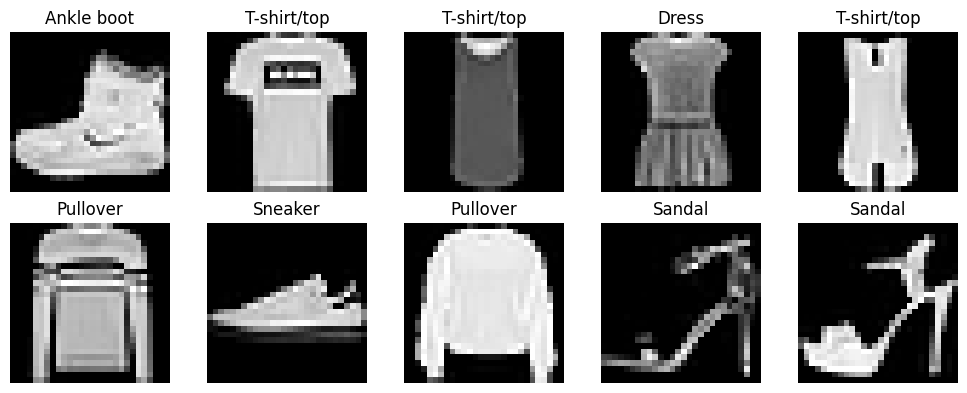

In [2]:
import matplotlib.pyplot as plt

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

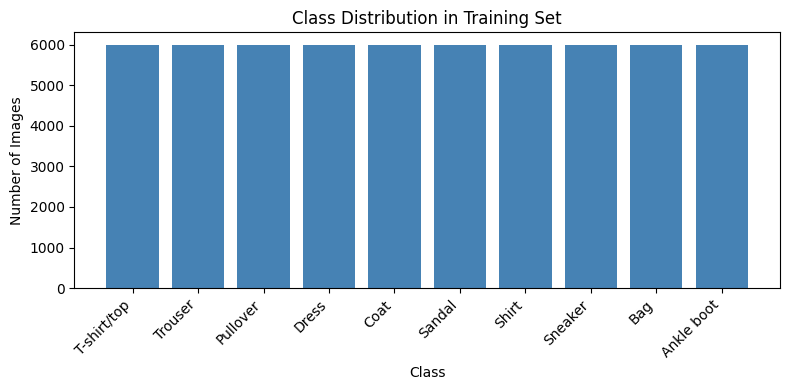

In [3]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in unique], counts, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Set")
plt.tight_layout()
plt.show()

In [4]:
#TASK 2
from tensorflow.keras.utils import to_categorical

# Print shapes BEFORE preprocessing
print("Before preprocessing:")
print("X_train:", X_train.shape, "| dtype:", X_train.dtype)
print("y_train:", y_train.shape, "| dtype:", y_train.dtype)
print("Sample pixel value range:", X_train.min(), "-", X_train.max())

# 1. Flatten: (60000, 28, 28) -> (60000, 784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Normalize: pixel values 0-255 -> 0-1
X_train_norm = X_train_flat.astype("float32") / 255.0
X_test_norm = X_test_flat.astype("float32") / 255.0

# 3. One-hot encode labels: e.g. 3 -> [0,0,0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Print shapes AFTER preprocessing
print("\nAfter preprocessing:")
print("X_train_norm:", X_train_norm.shape, "| dtype:", X_train_norm.dtype)
print("y_train_cat:", y_train_cat.shape, "| dtype:", y_train_cat.dtype)
print("Sample pixel value range:", X_train_norm.min(), "-", X_train_norm.max())
print("Sample label (before):", y_train[0], "-> (after):", y_train_cat[0])

Before preprocessing:
X_train: (60000, 28, 28) | dtype: uint8
y_train: (60000,) | dtype: uint8
Sample pixel value range: 0 - 255

After preprocessing:
X_train_norm: (60000, 784) | dtype: float32
y_train_cat: (60000, 10) | dtype: float64
Sample pixel value range: 0.0 - 1.0
Sample label (before): 9 -> (after): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [5]:
#TASK 3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from re import VERBOSE
#TASK 4
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train_norm, y_train_cat,
    validation_split=0.1,
    validation_data=(X_test_norm, y_test_cat),
    epochs=20,
    batch_size=32,
    verbose = 1
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8256 - loss: 0.4899 - val_accuracy: 0.8433 - val_loss: 0.4364
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8645 - loss: 0.3707 - val_accuracy: 0.8576 - val_loss: 0.3951
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8766 - loss: 0.3339 - val_accuracy: 0.8682 - val_loss: 0.3700
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8854 - loss: 0.3126 - val_accuracy: 0.8719 - val_loss: 0.3540
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8901 - loss: 0.2941 - val_accuracy: 0.8827 - val_loss: 0.3373
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8953 - loss: 0.2805 - val_accuracy: 0.8805 - val_loss: 0.3331
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8989 - loss: 0.2697 - val_accuracy: 0.8772 - val_loss: 0.3457
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9037 - loss: 0.2546 - 

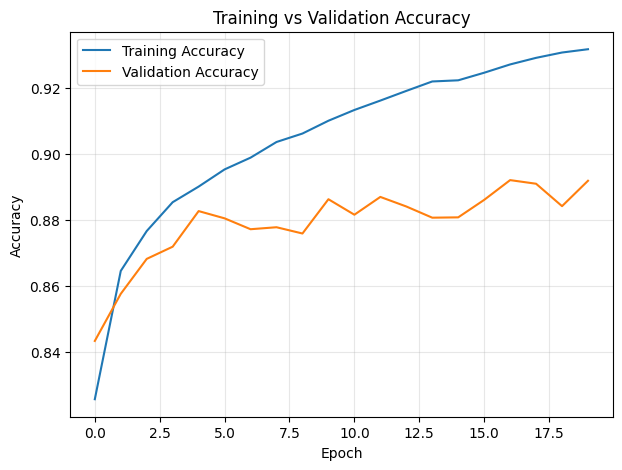

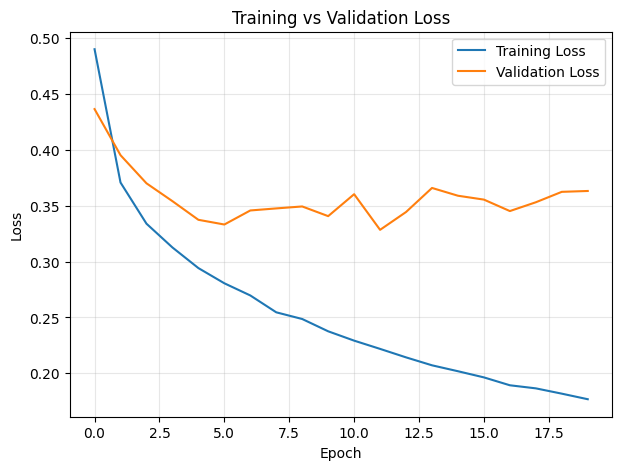

In [7]:
import matplotlib.pyplot as plt

# Plot 3 & 4: Training vs Validation Accuracy
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 5 & 6: Training vs Validation Loss
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
cm = confusion_matrix(y_true, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test Accuracy : 0.8919
Precision     : 0.8950
Recall        : 0.8919
F1-score      : 0.8927

Confusion Matrix:
 [[793   3  21  15   7   1 155   0   5   0]
 [  0 979   3  12   3   0   1   1   1   0]
 [ 12   1 792   5 104   0  85   0   1   0]
 [ 12  11  19 867  57   0  30   0   4   0]
 [  0   0  67  16 860   0  56   0   1   0]
 [  0   0   0   0   0 977   0  13   1   9]
 [ 69   2  65  25  75   0 755   0   9   0]
 [  0   0   0   0   0  15   0 962   0  23]
 [  3   0   4   4   7   4   5   2 971   0]
 [  0   0   0   0   0  13   1  23   0 963]]

Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.89      0.79      0.84      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.82      0.79      0.80      1000
       Dress       0.92      0.87      0.89      1000
        Coat       0.77      0.86      0.81      1000
      Sandal       0.97      0.98      0.97      1000
       Shirt

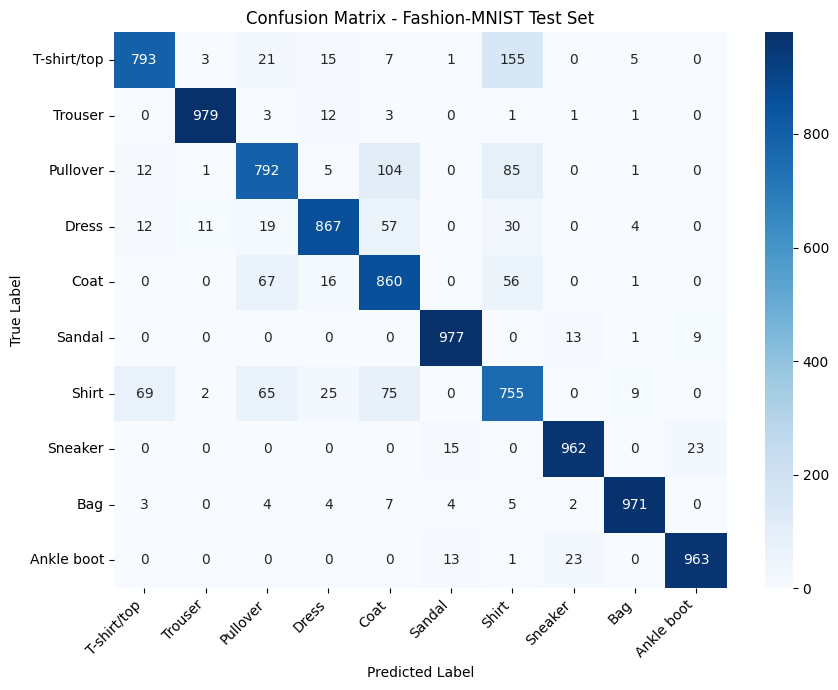

In [9]:
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fashion-MNIST Test Set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
pip install scikit-learn==1.5.2

In [11]:
pip install scikeras

In [12]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

def build_model(hidden_layers=2, neurons=128, learning_rate=0.001,
                 activation="relu", optimizer_name="adam", dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(Dense(neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    if optimizer_name == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [13]:
  model_wrapper = KerasClassifier(
    model=build_model,
    hidden_layers=2,
    neurons=128,
    learning_rate=0.001,
    activation="relu",
    optimizer_name="adam",
    dropout_rate=0.0,
    epochs=10,
    batch_size=32,
    verbose=0
)

In [14]:
from scipy.stats import randint

param_distributions = {
    "model__hidden_layers": [1, 2, 3],
    "model__neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
    "model__optimizer_name": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5]
}

In [15]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=model_wrapper,
    param_distributions=param_distributions,
    n_iter=3,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1
)

random_search_result = random_search.fit(X_train_norm, y_train_cat)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=  55.4s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=  43.5s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=  43.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate=0.001, model__neurons=256, model__optimizer_name=adam; total time=  43.8s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__learning_rate

In [17]:
print("Best Parameters:", random_search_result.best_params_)
print("Best Cross-Validation Accuracy:", random_search_result.best_score_)

Best Parameters: {'model__optimizer_name': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 1, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}
Best Cross-Validation Accuracy: 0.8882833333333334


In [18]:
best_params = random_search_result.best_params_

optimized_model = build_model(
    hidden_layers=best_params["model__hidden_layers"],
    neurons=best_params["model__neurons"],
    learning_rate=best_params["model__learning_rate"],
    activation=best_params["model__activation"],
    optimizer_name=best_params["model__optimizer_name"],
    dropout_rate=best_params["model__dropout_rate"]
)

optimized_history = optimized_model.fit(
    X_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8099 - loss: 0.5305 - val_accuracy: 0.8477 - val_loss: 0.4146
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8473 - loss: 0.4210 - val_accuracy: 0.8565 - val_loss: 0.3929
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8586 - loss: 0.3889 - val_accuracy: 0.8582 - val_loss: 0.3817
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8664 - loss: 0.3655 - val_accuracy: 0.8687 - val_loss: 0.3485
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8724 - loss: 0.3503 - val_accuracy: 0.8703 - val_loss: 0.3602
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8772 - loss: 0.3362 - val_accuracy: 0.8668 - val_loss: 0.3614
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8812 - loss: 0.3232 - val_accuracy: 0.8765 - val_loss: 0.3253
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8848 - loss: 0.3149 - val_accuracy: 0

In [19]:
y_pred_probs_opt = optimized_model.predict(X_test_norm)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)

acc_opt = accuracy_score(y_true, y_pred_opt)
prec_opt = precision_score(y_true, y_pred_opt, average="weighted")
rec_opt = recall_score(y_true, y_pred_opt, average="weighted")
f1_opt = f1_score(y_true, y_pred_opt, average="weighted")
cm_opt = confusion_matrix(y_true, y_pred_opt)

print(f"Optimized Test Accuracy : {acc_opt:.4f}")
print(f"Optimized Precision     : {prec_opt:.4f}")
print(f"Optimized Recall        : {rec_opt:.4f}")
print(f"Optimized F1-score      : {f1_opt:.4f}")
print("\nOptimized Confusion Matrix:\n", cm_opt)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Optimized Test Accuracy : 0.8828
Optimized Precision     : 0.8829
Optimized Recall        : 0.8828
Optimized F1-score      : 0.8825

Optimized Confusion Matrix:
 [[846   2  12  25   4   1 103   0   7   0]
 [  1 971   2  21   3   0   2   0   0   0]
 [ 14   0 810  14  93   0  69   0   0   0]
 [ 24   5   9 913  17   0  27   0   5   0]
 [  0   1 106  47 788   0  55   0   3   0]
 [  0   0   0   1   0 939   0  28   1  31]
 [122   2  91  29  60   0 691   0   5   0]
 [  0   0   0   0   0  18   0 925   0  57]
 [  2   0   5   6   5   2   4   4 972   0]
 [  0   0   0   0   0   2   1  24   0 973]]


      Metric  Baseline  Optimized
0   Accuracy  0.891900   0.882800
1  Precision  0.894970   0.882858
2     Recall  0.891900   0.882800
3   F1-score  0.892686   0.882539


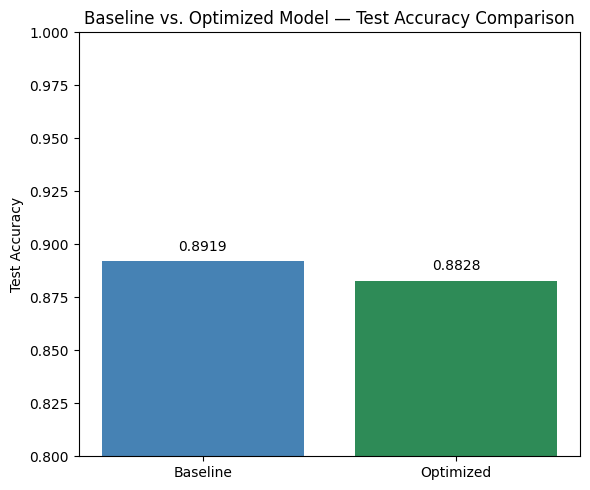

In [20]:
import pandas as pd
import time

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline": [acc, prec, rec, f1],
    "Optimized": [acc_opt, prec_opt, rec_opt, f1_opt]
})
print(comparison_df)

# Bar chart: mandatory plot 9 — Best Model Accuracy Comparison
plt.figure(figsize=(6, 5))
plt.bar(["Baseline", "Optimized"], [acc, acc_opt], color=["steelblue", "seagreen"])
plt.ylabel("Test Accuracy")
plt.title("Baseline vs. Optimized Model — Test Accuracy Comparison")
plt.ylim(0.8, 1.0)
for i, v in enumerate([acc, acc_opt]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha="center")
plt.tight_layout()
plt.show()

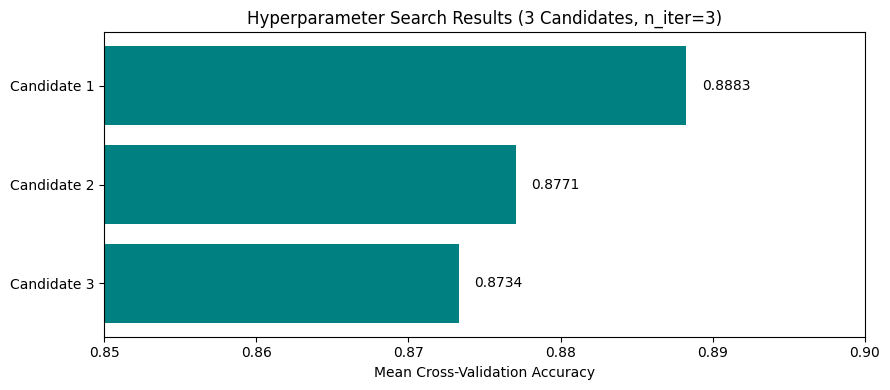

In [23]:
results_df = pd.DataFrame(random_search_result.cv_results_)
results_sorted = results_df.sort_values("mean_test_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 4))
plt.barh(range(len(results_sorted)), results_sorted["mean_test_score"], color="teal")
plt.yticks(range(len(results_sorted)),
           [f"Candidate {i+1}" for i in range(len(results_sorted))])
plt.xlabel("Mean Cross-Validation Accuracy")
plt.title("Hyperparameter Search Results (3 Candidates, n_iter=3)")
plt.xlim(0.85, 0.90)
for i, v in enumerate(results_sorted["mean_test_score"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
  print(random_search_result.cv_results_["params"])
print(random_search_result.cv_results_["mean_test_score"])

[{'model__optimizer_name': 'adam', 'model__neurons': 256, 'model__learning_rate': 0.001, 'model__hidden_layers': 1, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}, {'model__optimizer_name': 'rmsprop', 'model__neurons': 128, 'model__learning_rate': 0.001, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'sigmoid', 'epochs': 10, 'batch_size': 16}, {'model__optimizer_name': 'rmsprop', 'model__neurons': 32, 'model__learning_rate': 0.001, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}]
[0.88828333 0.8771     0.87335   ]
